# Random Forest for RUL Prediction - Using Processed Dataset

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
fd_001_train = pd.read_csv(r"data/processed/train_FD001_processed.csv")
fd_001_test = pd.read_csv(r"data/processed/test_FD001_processed.csv")

In [36]:
fd_001_train.describe()

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°K),LPC Outlet Temperature (°K),HPC Outlet Temperature (°K),LPT Outlet Temperature (°K),Fan Inlet Pressure (kPa),...,Corrected Fan Speed (rpm),Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,2.881500e+02,357.044963,883.623955,782.740990,100.801391,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,1.136896e-13,0.277807,3.406194,5.000336,0.000000,...,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,2.881500e+02,356.227778,872.800000,767.916667,100.801391,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,2.881500e+02,356.847222,881.255556,779.088889,100.801391,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,2.881500e+02,357.022222,883.388889,782.244444,100.801391,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,2.881500e+02,357.222222,885.766667,785.863889,100.801391,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,2.881500e+02,358.072222,898.283333,800.827778,100.801391,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


In [37]:
fd_001_train['life_ratio'] = fd_001_train['cycle'] / fd_001_train.groupby('engine')['cycle'].transform('max') 
fd_001_train

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°K),LPC Outlet Temperature (°K),HPC Outlet Temperature (°K),LPT Outlet Temperature (°K),Fan Inlet Pressure (kPa),...,Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL,life_ratio
0,1,1,-0.0007,-0.0004,100.0,288.15,356.566667,883.166667,778.111111,100.801391,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0,0.005208
1,1,2,0.0019,-0.0003,100.0,288.15,356.750000,884.344444,779.522222,100.801391,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0,0.010417
2,1,3,-0.0043,0.0003,100.0,288.15,356.861111,882.216667,780.111111,100.801391,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0,0.015625
3,1,4,0.0007,0.0000,100.0,288.15,356.861111,879.327778,778.816667,100.801391,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0,0.020833
4,1,5,-0.0019,-0.0002,100.0,288.15,356.872222,879.361111,781.233333,100.801391,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0,0.026042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,288.15,357.494444,887.766667,793.683333,100.801391,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4.0,0.980000
20627,100,197,-0.0016,-0.0005,100.0,288.15,357.522222,891.388889,796.433333,100.801391,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3.0,0.985000
20628,100,198,0.0004,0.0000,100.0,288.15,357.455556,890.255556,793.433333,100.801391,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2.0,0.990000
20629,100,199,-0.0011,0.0003,100.0,288.15,357.350000,891.811111,792.516667,100.801391,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1.0,0.995000


In [38]:
fd_001_train[fd_001_train['engine'] == 2]

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°K),LPC Outlet Temperature (°K),HPC Outlet Temperature (°K),LPT Outlet Temperature (°K),Fan Inlet Pressure (kPa),...,Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL,life_ratio
192,2,1,-0.0018,0.0006,100.0,288.15,356.605556,879.911111,772.933333,100.801391,...,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585,286.0,0.003484
193,2,2,0.0043,-0.0003,100.0,288.15,356.566667,881.694444,773.961111,100.801391,...,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085,285.0,0.006969
194,2,3,0.0018,0.0003,100.0,288.15,356.416667,882.400000,777.200000,100.801391,...,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250,284.0,0.010453
195,2,4,0.0035,-0.0004,100.0,288.15,356.488889,880.083333,775.600000,100.801391,...,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027,283.0,0.013937
196,2,5,0.0005,0.0004,100.0,288.15,356.516667,877.238889,779.177778,100.801391,...,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234,282.0,0.017422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,2,283,0.0046,0.0002,100.0,288.15,357.655556,890.016667,794.261111,100.801391,...,8174.85,8.5199,0.03,398,2388,100.0,38.42,23.0358,4.0,0.986063
475,2,284,-0.0006,0.0001,100.0,288.15,357.727778,889.638889,794.466667,100.801391,...,8166.83,8.5291,0.03,395,2388,100.0,38.23,23.1196,3.0,0.989547
476,2,285,-0.0007,0.0004,100.0,288.15,357.594444,887.133333,795.094444,100.801391,...,8164.83,8.5242,0.03,396,2388,100.0,38.39,23.1155,2.0,0.993031
477,2,286,-0.0010,-0.0003,100.0,288.15,357.466667,890.905556,794.205556,100.801391,...,8169.97,8.4932,0.03,395,2388,100.0,38.33,23.0169,1.0,0.996516


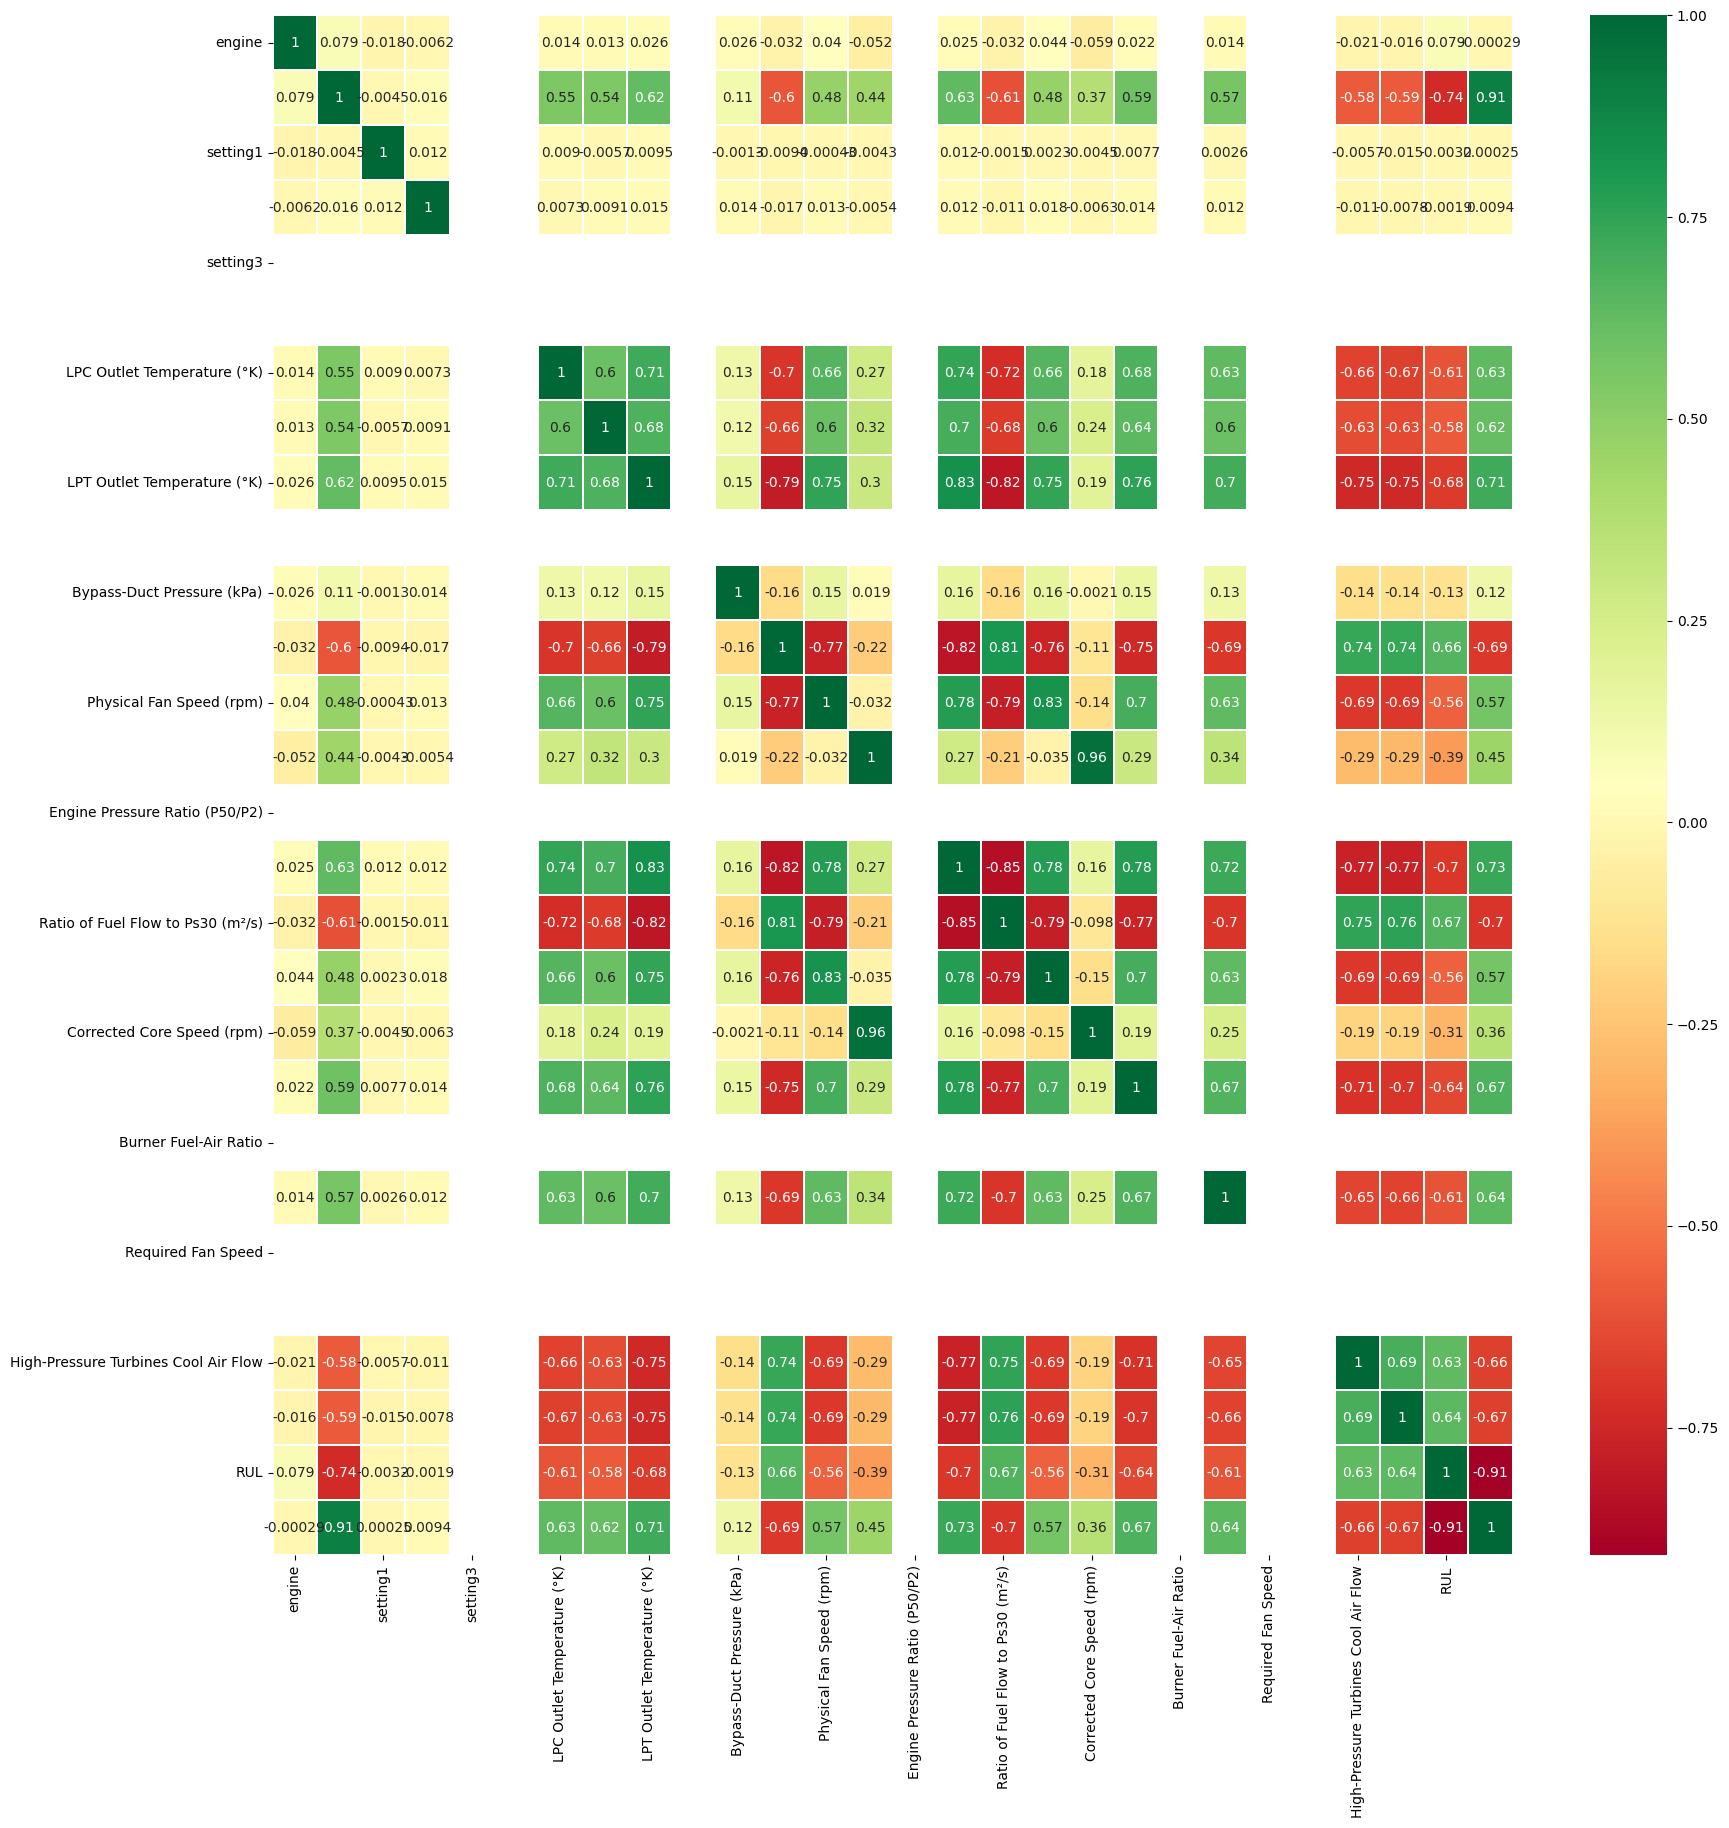

In [39]:
sns.heatmap(fd_001_train.corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [41]:
# Drop non-predictive columns
X = fd_001_train.drop(columns=['engine', 'setting1', 'setting2', 'setting3', 'life_ratio', 'RUL'])
y = fd_001_train['life_ratio']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# Predict and evaluate on validation set
y_pred_val = model.predict(X_test)
mse_val = mean_squared_error(y_test, y_pred_val)
print(f'Validation Mean Squared Error: {mse_val}')

Validation Mean Squared Error: 0.0036368870558909283


# Validation Set Visualization
Plot prediction results on validation set (20% split from training data)

Engines in validation set: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]...


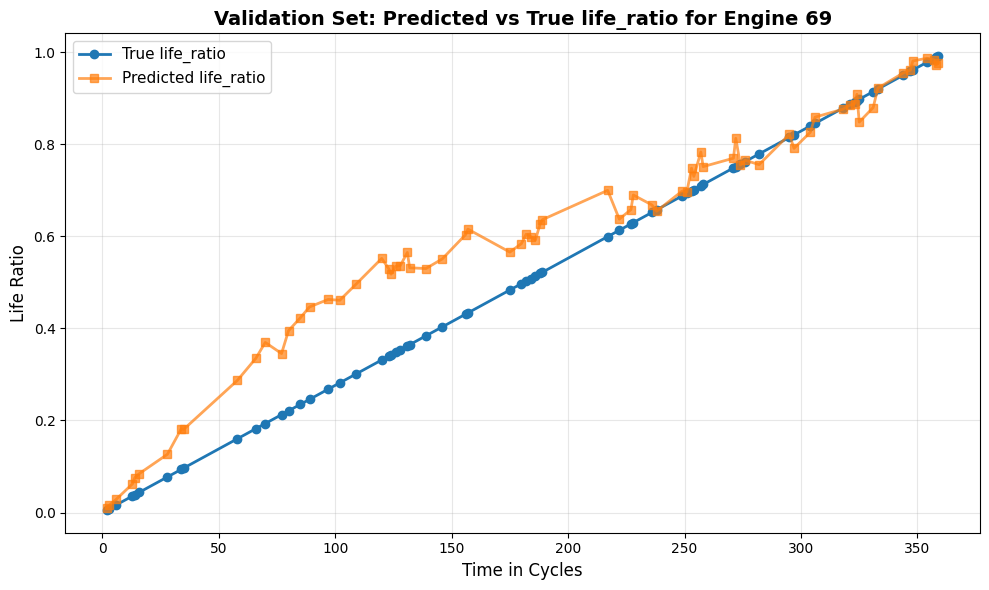


Validation Engine 69 has 72 data points in validation set


In [43]:
# Create a dataframe with validation set results to identify engines
# We need to map back the validation indices to original engine IDs and cycles
validation_indices = X_test.index
validation_data = fd_001_train.loc[validation_indices].copy()
validation_data['predicted_life_ratio'] = y_pred_val
validation_data['true_life_ratio'] = y_test.values

# Select an engine from validation set
available_engines = validation_data['engine'].unique()
print(f"Engines in validation set: {sorted(available_engines)[:10]}...")  # Show first 10
selected_engine = available_engines[0]  # Select first engine in validation set

# Get data for this engine
engine_val_data = validation_data[validation_data['engine'] == selected_engine].sort_values('cycle')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(engine_val_data['cycle'], engine_val_data['true_life_ratio'], 
         label='True life_ratio', marker='o', linewidth=2, markersize=6)
plt.plot(engine_val_data['cycle'], engine_val_data['predicted_life_ratio'], 
         label='Predicted life_ratio', marker='s', linewidth=2, markersize=6, alpha=0.7)
plt.xlabel('Time in Cycles', fontsize=12)
plt.ylabel('Life Ratio', fontsize=12)
plt.title(f'Validation Set: Predicted vs True life_ratio for Engine {selected_engine}', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nValidation Engine {selected_engine} has {len(engine_val_data)} data points in validation set")

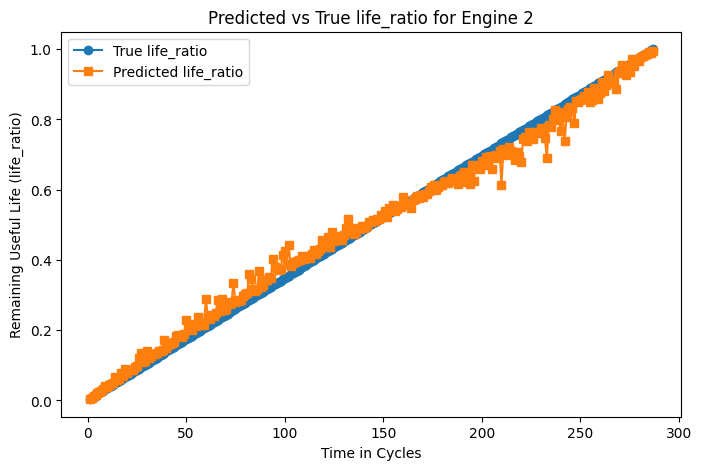

In [44]:
# Plot predicted vs true life_ratio for a specific engine
engine_id = fd_001_train['engine'].unique()[1]  # Select the second engine
engine_data = fd_001_train[fd_001_train['engine'] == engine_id]
true_life_ratio = engine_data['life_ratio']
pred_life_ratio = model.predict(engine_data.drop(columns=['engine', 'setting1', 'setting2', 'setting3', 'life_ratio', 'RUL']))

plt.figure(figsize=(8, 5))
plt.plot(engine_data['cycle'], true_life_ratio, label='True life_ratio', marker='o')
plt.plot(engine_data['cycle'], pred_life_ratio, label='Predicted life_ratio', marker='s')
plt.xlabel('Time in Cycles')
plt.ylabel('Remaining Useful Life (life_ratio)')
plt.title(f'Predicted vs True life_ratio for Engine {engine_id}')
plt.legend()
plt.show()

# Test on test dataset

In [49]:
# Prepare test data - calculate life_ratio using fixed EOL (End of Life) per engine
# This matches the original implementation where eol is constant for each engine

# Create eol list: for each engine, use the LAST cycle's RUL value as a constant
eol = []
for engine_num in fd_001_test['engine'].unique():
    engine_mask = fd_001_test['engine'] == engine_num
    # Get the RUL at the last cycle (maximum cycle) for this engine
    last_cycle_idx = fd_001_test[engine_mask]['cycle'].idxmax()
    eol_value = fd_001_test.loc[last_cycle_idx, 'RUL']
    # Repeat this constant value for all rows of this engine
    num_rows = engine_mask.sum()
    eol.extend([eol_value] * num_rows)

# Calculate life_ratio with constant eol per engine
max_cycles = fd_001_test.groupby('engine')['cycle'].transform('max')
fd_001_test['life_ratio'] = fd_001_test['cycle'].values / (max_cycles.values + eol)
fd_001_test.head()

,engine,cycle,setting1,setting2,setting3,Fan Inlet Temperature (°K),LPC Outlet Temperature (°K),HPC Outlet Temperature (°K),LPT Outlet Temperature (°K),Fan Inlet Pressure (kPa),...,Corrected Core Speed (rpm),Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL,life_ratio
0,1,1,0.0023,0.0003,100.0,288.15,357.233333,880.716667,776.783333,100.801391,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142,0.006993
1,1,2,-0.0027,-0.0003,100.0,288.15,356.505556,882.472222,775.233333,100.801391,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141,0.013986
2,1,3,0.0003,0.0001,100.0,288.15,356.922222,881.633333,778.522222,100.801391,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140,0.020979
3,1,4,0.0042,0.0000,100.0,288.15,356.911111,880.066667,781.344444,100.801391,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139,0.027972
4,1,5,0.0014,0.0000,100.0,288.15,356.950000,881.772222,778.844444,100.801391,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138,0.034965


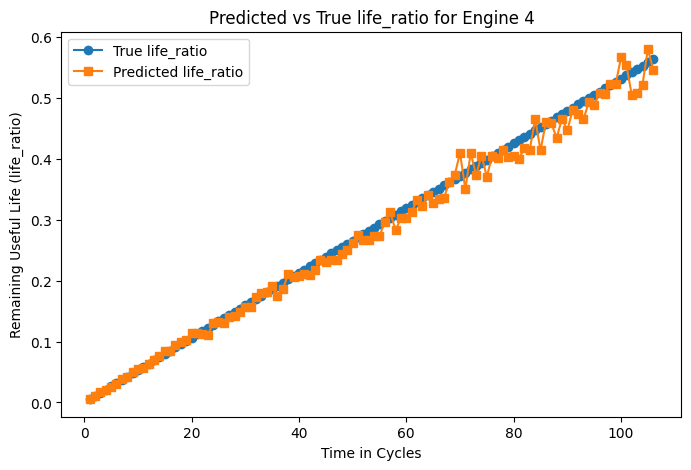

In [50]:
# Plot predicted vs true life_ratio for a specific engine from test set
engine_id = fd_001_test['engine'].unique()[3]  # Select the 4th engine
engine_data = fd_001_test[fd_001_test['engine'] == engine_id]
true_life_ratio = engine_data['life_ratio']
pred_life_ratio = model.predict(engine_data.drop(columns=['engine', 'setting1', 'setting2', 'setting3', 'life_ratio', 'RUL']))

plt.figure(figsize=(8, 5))
plt.plot(engine_data['cycle'], true_life_ratio, label='True life_ratio', marker='o')
plt.plot(engine_data['cycle'], pred_life_ratio, label='Predicted life_ratio', marker='s')
plt.xlabel('Time in Cycles')
plt.ylabel('Remaining Useful Life (life_ratio)')
plt.title(f'Predicted vs True life_ratio for Engine {engine_id}')
plt.legend()
plt.show()

In [47]:
# Evaluate on entire test set
X_test_full = fd_001_test.drop(columns=['engine', 'setting1', 'setting2', 'setting3', 'life_ratio', 'RUL'])
y_test_full = fd_001_test['life_ratio']

y_pred = model.predict(X_test_full)
mse = mean_squared_error(y_test_full, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.010286577528999044


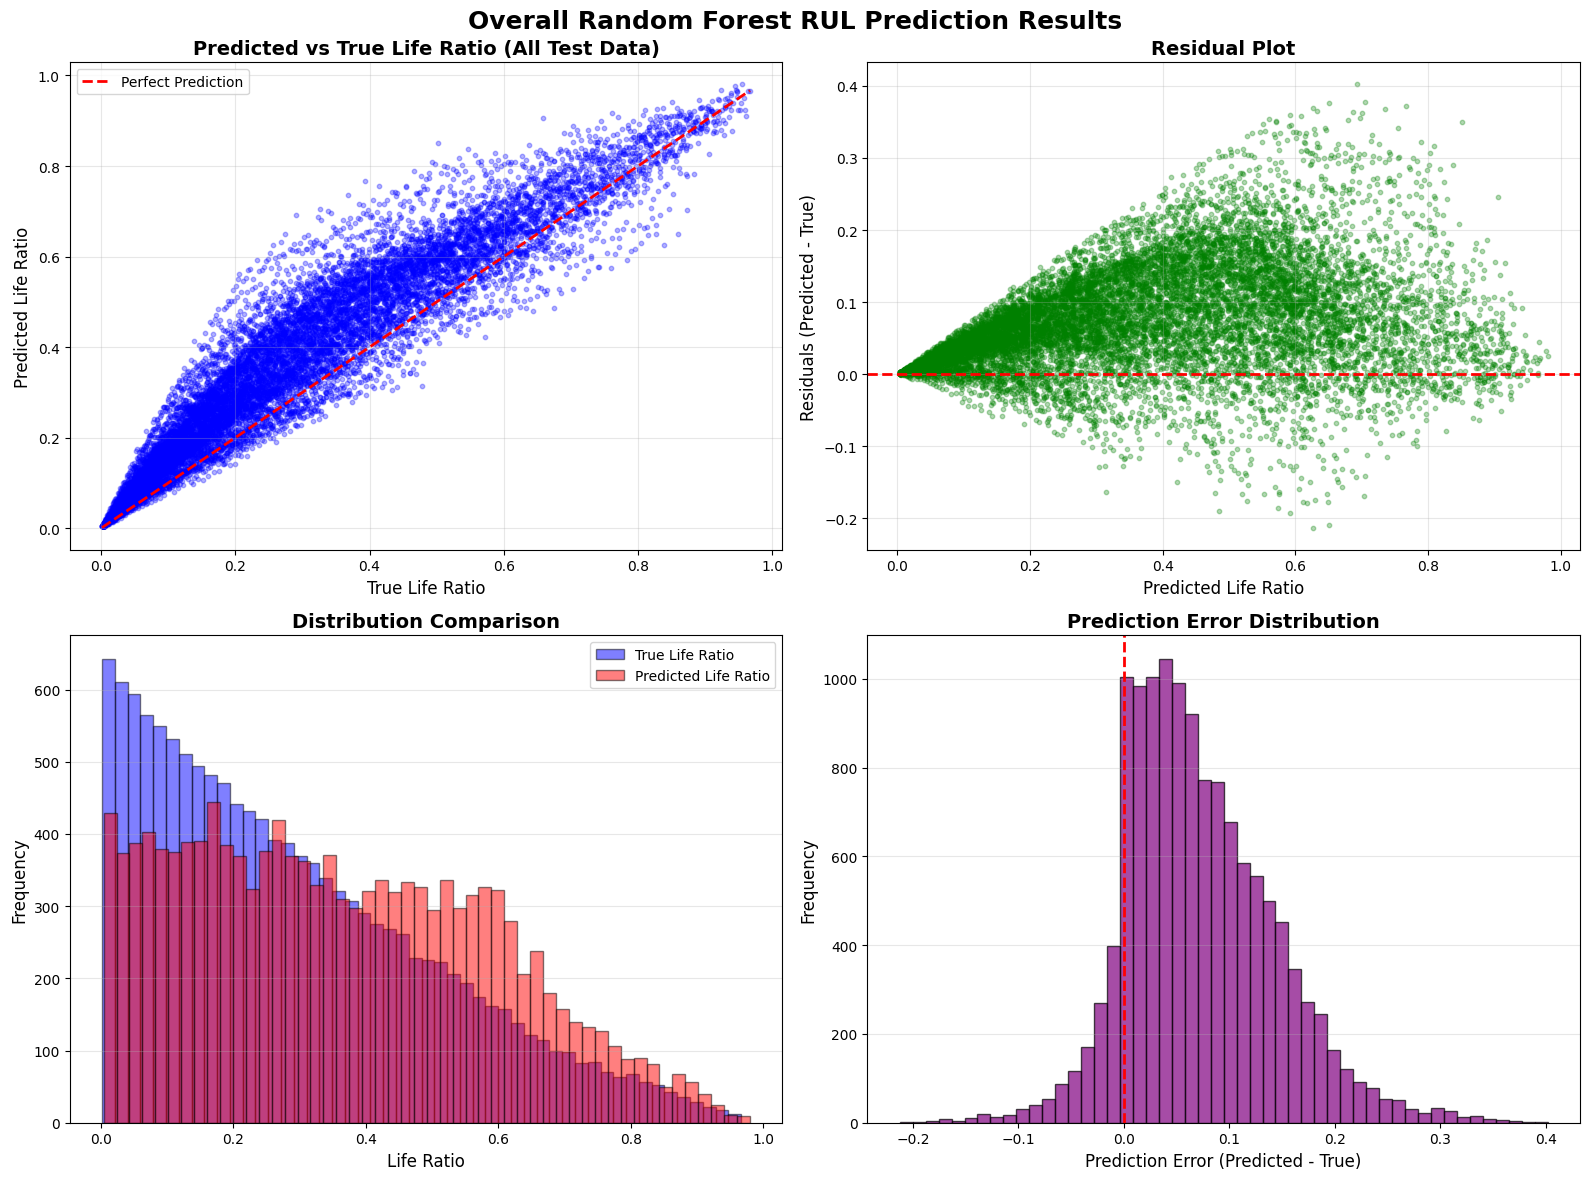


OVERALL MODEL PERFORMANCE SUMMARY
Total samples tested: 13096
Mean Squared Error (MSE): 0.010287
Root Mean Squared Error (RMSE): 0.101423
Mean Absolute Error (MAE): 0.079008
R² Score: 0.7800

Mean Residual: 0.071741
Std Residual: 0.071693
Min Residual: -0.212652
Max Residual: 0.401888


In [48]:
# Overall Results Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Overall Random Forest RUL Prediction Results', fontsize=18, fontweight='bold')

# 1. Predicted vs True scatter plot
ax1 = axes[0, 0]
ax1.scatter(y_test_full, y_pred, alpha=0.3, s=10, c='blue')
ax1.plot([y_test_full.min(), y_test_full.max()], [y_test_full.min(), y_test_full.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Life Ratio', fontsize=12)
ax1.set_ylabel('Predicted Life Ratio', fontsize=12)
ax1.set_title('Predicted vs True Life Ratio (All Test Data)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Residual plot
ax2 = axes[0, 1]
residuals = y_pred - y_test_full
ax2.scatter(y_pred, residuals, alpha=0.3, s=10, c='green')
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Life Ratio', fontsize=12)
ax2.set_ylabel('Residuals (Predicted - True)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Distribution comparison
ax3 = axes[1, 0]
ax3.hist(y_test_full, bins=50, alpha=0.5, label='True Life Ratio', color='blue', edgecolor='black')
ax3.hist(y_pred, bins=50, alpha=0.5, label='Predicted Life Ratio', color='red', edgecolor='black')
ax3.set_xlabel('Life Ratio', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Error distribution
ax4 = axes[1, 1]
ax4.hist(residuals, bins=50, alpha=0.7, color='purple', edgecolor='black')
ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Prediction Error (Predicted - True)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print overall statistics
print("\n" + "="*70)
print("OVERALL MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"Total samples tested: {len(y_test_full)}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.6f}")
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(residuals)):.6f}")
print(f"R² Score: {1 - (np.sum((y_test_full - y_pred)**2) / np.sum((y_test_full - np.mean(y_test_full))**2)):.4f}")
print(f"\nMean Residual: {np.mean(residuals):.6f}")
print(f"Std Residual: {np.std(residuals):.6f}")
print(f"Min Residual: {np.min(residuals):.6f}")
print(f"Max Residual: {np.max(residuals):.6f}")
print("="*70)